## DEFINING FUNCTIONS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import eye, ones
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from torch.distributions import MultivariateNormal
from joblib import Parallel, delayed
from sbi.analysis import pairplot, marginal_plot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)


# Define likelihood function, ~N(\theta+loc, diag(scale)) in num_dims dimensions
def simulator(theta, loc, scale):
    """linear gaussian inspired by sbibm
    https://github.com/sbi-benchmark/sbibm/blob/15f068a08a938383116ffd92b92de50c580810a3/sbibm/tasks/gaussian_linear/task.py#L74
    """
    num_dim = theta.shape[-1]
    cov_ = scale * eye(num_dim)  # always positively semi-definite

    # using validate_args=False disables sanity checks on `covariance_matrix`
    # for the sake of speed
    value = MultivariateNormal(
        loc=(theta + loc), covariance_matrix=cov_, validate_args=False
    ).sample()
    return value


def noisy_correlated_simulator(theta, loc, scale, eps):
    num_dim = theta.shape[-1]
    device, dtype = theta.device, theta.dtype

    cov_ = scale * torch.eye(num_dim, device=device, dtype=dtype)

    # add small constant off-diagonal covariance
    off = eps * scale * (torch.ones((num_dim, num_dim), device=device, dtype=dtype) - torch.eye(num_dim, device=device, dtype=dtype))
    cov_ = cov_ + off

    value = MultivariateNormal(loc=(theta + loc), covariance_matrix=cov_, validate_args=False).sample()
    return value

# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(num_dim, num_simulations):
    prior_mean = ones(num_dim)      #mean vector [1,1]
    prior_cov = 2 * eye(num_dim)       # cov of 2* identity matrix
    prior = MultivariateNormal(
    loc=prior_mean, covariance_matrix=prior_cov, validate_args=False
    )
    
    theta = prior.sample((num_simulations,))
    return prior, theta

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        if getattr(x_obs, "ndim", None) == 2 and x_obs.shape[0] == 1:
            x_obs = x_obs[0]    
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        figsize=(4, 4),
    )

# cd /mnt/c/Users/vasir/Documents/0\ Research\ Project

In [2]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val, loc, scale):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(training_batch_size=200,max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior_direct = inference.build_posterior(density_estimator=posterior_net,sample_with="direct")
    posterior_mcmc = inference.build_posterior(density_estimator=posterior_net,sample_with="mcmc")
    samples = posterior_direct.sample((10_000,), x=x_obs)
    predictive_samples = simulator(samples,loc,scale)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples=samples,
            points=true_val,
            limits=list(zip(true_val.flatten() - 1.0, true_val.flatten() + 1.0, strict=False)),
            upper="kde",
            diag="kde",
            figsize=(5, 5),
            labels=[rf"$\theta_{d}$" for d in range(samples.shape[1])],
            )

        _ = pairplot(
            samples=predictive_samples,
            points=x_obs,
            limits=list(zip(x_obs.flatten() - 1.0, x_obs.flatten() + 1.0, strict=False)),
            upper="kde",
            diag="kde",
            figsize=(5, 5),
            labels=[rf"$x_{d}$" for d in range(3)], # this range is probbaly not future proof
            )
   
    return samples, posterior_mcmc, posterior_direct, inference

## MODEL TRAINING

In [3]:
num_dim = 2 # 2d gaussian
num_simulations = 10_000    # no of training pairs we generate
max_epoch = 150

# these are our noise parameters
loc1 = 0.05 
scale1 = 0.03

loc2 = loc1 #-0.02
scale2 = scale1 # 0.1

eps = 0.5


prior, theta=choose_prior_and_generate_theta(num_dim, num_simulations)

x1 = simulator(theta,loc1, scale1) # noisy draws
x2 = noisy_correlated_simulator(theta,loc2, scale2, eps) # noisy draws

#noisy_correlated_simulator(theta, loc, scale, eps)

theta_observed = prior.sample((1,))
x_obs1 = simulator(theta_observed,loc1, scale1) # noise added
x_obs2=noisy_correlated_simulator(theta_observed,loc2, scale2, eps) # noise added


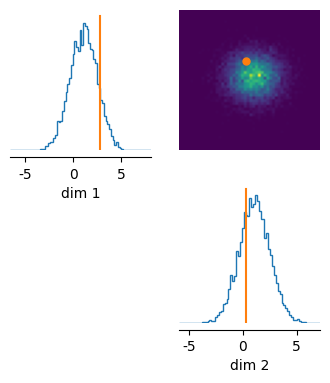

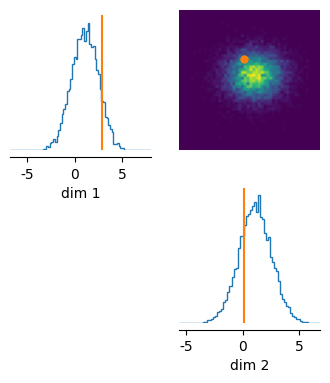

In [4]:
# Prior checks: does observation fall in prior support
plot_checker(x1,x_obs1)
plot_checker(x2,x_obs2)

In [5]:
samples1, posterior1_mcmc, posterior1_direct, inference1 = train_net_generate_samples(x1,theta,x_obs1, prior, verbose = True, max_epoch=max_epoch, true_val=theta_observed, loc=loc1, scale=scale1)

 Training neural network. Epochs trained: 13

KeyboardInterrupt: 

 Neural network successfully converged after 106 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\2D Gaussian Example\sbi-logs\NPE_C\2026-02-17T13_18_47.275332' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([[2.8390, 0.0925]])


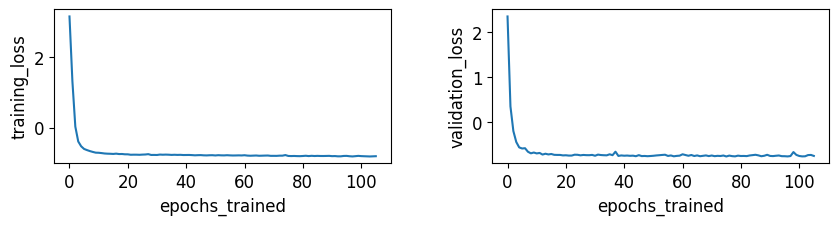

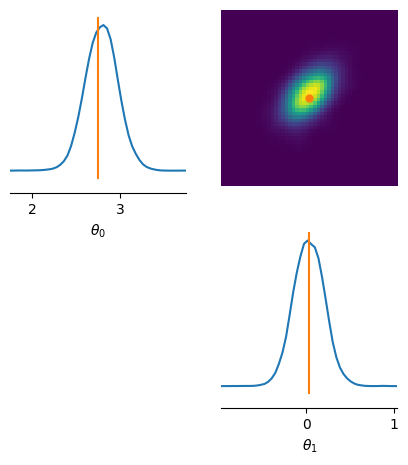

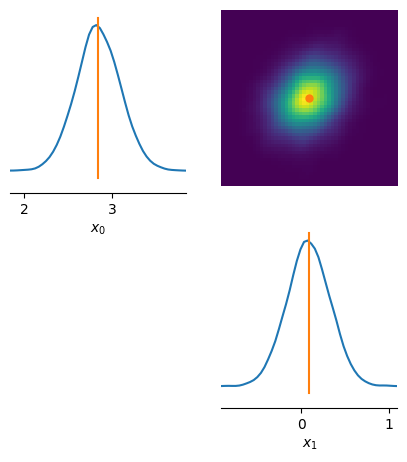

In [24]:
samples2, posterior2_mcmc, posterior2_direct, inference2 = train_net_generate_samples(x2,theta,x_obs2, prior, verbose = True, max_epoch=max_epoch, true_val=theta_observed, loc=loc2, scale=scale2)

## POSTERIOR CHECKS/SBC - Needs adapting still

In [7]:
'''
posterior_samples = posterior1_mcmc.sample((10,), x=x_obs)
posterior_predictives = parallel_simulate(posterior_samples)

posterior_predictive_summary_stats = torch.as_tensor(
    np.asarray([summarize_simulation(sim) for sim in simulation_outputs]),
    dtype=torch.float32
)
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
_ = ax.plot(time_vec, observation[:, 0], c="b")
_ = ax.plot(time_vec, observation[:, 1], c="orange")
for i in range(10):
    _ = ax.plot(time_vec, posterior_predictives[i, :, 0], c="b", alpha=0.2)
    _ = ax.plot(time_vec, posterior_predictives[i, :, 1], c="orange", alpha=0.2)
_ = ax.legend(["Prey", "Predator"])
_ = ax.set_xlabel("Time")
_ = ax.set_ylabel("Population")

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s

prior_samples = prior.sample((num_sbc_samples,))

prior_predictives = parallel_simulate(prior_samples)
prior_predictive_summary_stats = torch.as_tensor(
    np.asarray([summarize_simulation(sim) for sim in prior_predictives]),
    dtype=torch.float32
)

from sbi.diagnostics import run_sbc

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 1_000
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictive_summary_stats,
    posterior,
    reduce_fns=lambda theta, x: -posterior.log_prob(theta, x),
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)

from sbi.analysis.plot import sbc_rank_plot

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    plot_type="cdf",
    num_bins=20,
    figsize=(5, 3),
)


'''

'\nposterior_samples = posterior1_mcmc.sample((10,), x=x_obs)\nposterior_predictives = parallel_simulate(posterior_samples)\n\nposterior_predictive_summary_stats = torch.as_tensor(\n    np.asarray([summarize_simulation(sim) for sim in simulation_outputs]),\n    dtype=torch.float32\n)\nfig, ax = plt.subplots(1, 1, figsize=(6, 3))\n_ = ax.plot(time_vec, observation[:, 0], c="b")\n_ = ax.plot(time_vec, observation[:, 1], c="orange")\nfor i in range(10):\n    _ = ax.plot(time_vec, posterior_predictives[i, :, 0], c="b", alpha=0.2)\n    _ = ax.plot(time_vec, posterior_predictives[i, :, 1], c="orange", alpha=0.2)\n_ = ax.legend(["Prey", "Predator"])\n_ = ax.set_xlabel("Time")\n_ = ax.set_ylabel("Population")\n\nnum_sbc_samples = 200  # choose a number of sbc runs, should be ~100s\n\nprior_samples = prior.sample((num_sbc_samples,))\n\nprior_predictives = parallel_simulate(prior_samples)\nprior_predictive_summary_stats = torch.as_tensor(\n    np.asarray([summarize_simulation(sim) for sim in pri

## SAVING RESULTS

In [26]:
results = {
        "samples1": samples1,          # posterior samples (1000, 2)
        "samples2": samples2,          # posterior samples (1000, 2)
        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)
        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)
        "inference1": inference1,      # NPE object
        "inference2": inference2,      # NPE object
        "prior": prior,
        "theta": theta,              # simulated Î¸ used for training (10000, 4)
        "x1": x1,
        "x2": x2,                                   # 
        "x_obs1": x_obs1,              # 
        "x_obs2": x_obs2,
        "loc1": loc1,
        "loc2" : loc2,
        "scale1": scale1, 
        "scale2": scale2,
        "theta_observed": theta_observed,
        "eps": eps                      
    }


fname = f"off_diag_CALIBRATION TESTER_gaussian_loc1_{eps}.pt"
torch.save(results, fname)

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\torch\serialization.py:1088: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  pickler.dump(obj)


## KL CALIBRATION CODE

#### Loading Results and Plots to check

In [3]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior",
        "theta",
        "x1", "x2",
        "x_obs1", "x_obs2",
        "loc1","loc2", 
        "scale1","scale2", "theta_observed",
        "eps"
        
    ]

    

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [4]:
fname1 = "off_diag_CALIBRATION TESTER_gaussian_loc1.pt"
fname2 = "off_diag_CALIBRATION TESTER_gaussian_loc1_0.5.pt"


res = load_results_file(fname2)
# update to include t_span when we retrain models
# update to include true_params if needed but think first
(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior,
 theta,
 x1, x2,
 x_obs1, x_obs2,
 loc1, loc2, scale1, scale2, theta_observed, eps
) = extract_results(res)

C:\Users\vasir\AppData\Local\Temp\ipykernel_8524\293419691.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


#### Need adjusting for off-diag

In [5]:
# Define analytical solutions: 

def posterior_params(x_obs, loc, scale):
    x_obs = torch.as_tensor(x_obs)
    loc   = torch.as_tensor(loc, dtype=x_obs.dtype, device=x_obs.device)
    s     = torch.as_tensor(scale, dtype=x_obs.dtype, device=x_obs.device)  # variance

    mu_post = (s * torch.ones_like(x_obs) + 2 * (x_obs - loc)) / (s + 2)
    Sigma_post = (2 * s / (s + 2)) * torch.eye(x_obs.numel(), dtype=x_obs.dtype, device=x_obs.device)
    return mu_post, Sigma_post

def posterior_params_correlated(x_obs, loc, scale, eps, prior=None):
    """
    2D conjugate posterior with correlated Gaussian likelihood.

    Prior:
        theta ~ N(mu0, Sigma0)
        default: mu0=[1,1], Sigma0=2I

    Likelihood:
        x_obs | theta ~ N(theta + loc*1, Sigma_L)
        Sigma_L = scale * [[1, eps],
                           [eps, 1]]
    where eps is the correlation coefficient (rho).

    Parameters
    ----------
    x_obs : (2,) tensor/array
    loc   : scalar shift (applied to both dims)
    scale : scalar variance (diagonal variance)
    eps   : correlation coefficient in (-1, 1)
    prior : torch.distributions.MultivariateNormal (optional)

    Returns
    -------
    mu_post : (2,) tensor
    Sigma_post : (2,2) tensor
    """
    x_obs = torch.as_tensor(x_obs)
    loc   = torch.as_tensor(loc, dtype=x_obs.dtype, device=x_obs.device)
    s     = torch.as_tensor(scale, dtype=x_obs.dtype, device=x_obs.device)  # variance
    rho   = torch.as_tensor(eps,   dtype=x_obs.dtype, device=x_obs.device)

    if x_obs.numel() != 2:
        raise ValueError(f"Expected 2D observation, got shape {tuple(x_obs.shape)}")
    if not torch.all(torch.abs(rho) < 1):
        raise ValueError(f"Need |eps| < 1 since eps is correlation. Got eps={rho.item()}")

    # Prior (default matches your notebook)
    if prior is None:
        mu0 = torch.ones(2, dtype=x_obs.dtype, device=x_obs.device)
        Sigma0 = 2.0 * torch.eye(2, dtype=x_obs.dtype, device=x_obs.device)
    else:
        mu0 = prior.loc.to(dtype=x_obs.dtype, device=x_obs.device)
        Sigma0 = prior.covariance_matrix.to(dtype=x_obs.dtype, device=x_obs.device)

    # Likelihood covariance from correlation coefficient
    SigmaL = s * torch.tensor([[1.0, rho],
                               [rho, 1.0]], dtype=x_obs.dtype, device=x_obs.device)

    # Posterior covariance: (Sigma0^{-1} + SigmaL^{-1})^{-1}
    I = torch.eye(2, dtype=x_obs.dtype, device=x_obs.device)
    Sigma0_inv = torch.linalg.solve(Sigma0, I)
    SigmaL_inv = torch.linalg.solve(SigmaL, I)
    Sigma_post = torch.linalg.solve(Sigma0_inv + SigmaL_inv, I)

    # Posterior mean: Sigma_post (Sigma0^{-1} mu0 + SigmaL^{-1} (x-loc))
    d = x_obs.reshape(2) - loc  # subtract loc from both components
    eta = Sigma0_inv @ mu0 + SigmaL_inv @ d
    mu_post = Sigma_post @ eta

    return mu_post, Sigma_post


mu_post1, Sigma_post1 = posterior_params(x_obs1, loc1, scale1)
mu_post2, Sigma_post2 = posterior_params_correlated(x_obs2, loc2, scale2, eps, prior=prior)

Text(0.5, 1.05, 'SBI vs analytic marginals, split 2')

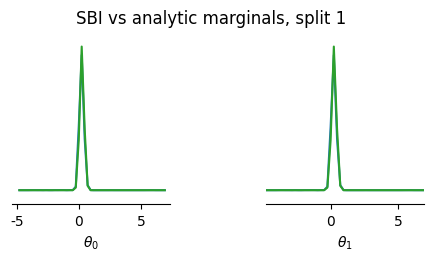

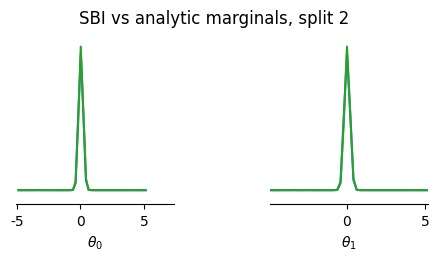

In [6]:
# Plot posteriors vs analytic solutions to check training: 


analytic_samples1 = MultivariateNormal(mu_post1, Sigma_post1, validate_args=False).sample((20_000,)).reshape(-1, 2)
analytic_samples2 = MultivariateNormal(mu_post2, Sigma_post2, validate_args=False).sample((20_000,)).reshape(-1, 2)

fig1, ax1 = marginal_plot(
    samples=[samples1, analytic_samples1],
    diag=["kde", "kde"],
    labels=[r"$\theta_0$", r"$\theta_1$"],
    figsize=(6, 2),
)
fig1.suptitle("SBI vs analytic marginals, split 1", y=1.05)

fig2, ax2 = marginal_plot(
    samples=[samples2, analytic_samples2],
    diag=["kde", "kde"],
    labels=[r"$\theta_0$", r"$\theta_1$"],
    figsize=(6, 2),
)
fig2.suptitle("SBI vs analytic marginals, split 2", y=1.05)



C:\Users\vasir\AppData\Local\Temp\ipykernel_26192\269439668.py:54: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(XX, YY, ZZ, levels=6, colors="black", linewidths=1.0, alpha=0.8, label="Analytic posterior")


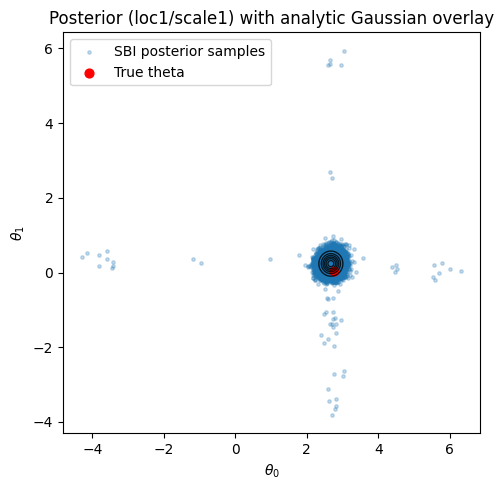

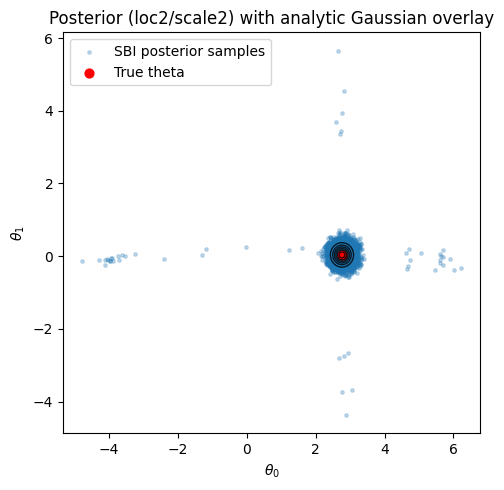

In [11]:
### Note this cell is gpt generated playing around with codex in vs code


# Overlay analytical Gaussian posterior on top of SBI posterior samples (2D only)
def analytic_posterior_gaussian(
    prior_mean,
    prior_cov,
    x_obs,
    loc,
    scale,
    eps=None,
    likelihood_cov=None,
):
    """
    Closed-form posterior for:
      prior:  theta ~ N(mu0, Sigma0)
      likelihood: x | theta ~ N(theta + loc, Sigma_lik)

    Sigma_lik is built as:
      - isotropic: scale * I
      - with constant off-diagonal correlation: scale * I + eps * (1 - I)
      - or directly supplied as `likelihood_cov` (full covariance matrix)
    """
    mu0 = prior_mean.reshape(-1, 1)
    Sigma0 = prior_cov
    num_dim = Sigma0.shape[-1]

    dtype = Sigma0.dtype
    device = Sigma0.device
    eye = torch.eye(num_dim, dtype=dtype, device=device)

    if likelihood_cov is not None:
        Sigma_lik = torch.as_tensor(likelihood_cov, dtype=dtype, device=device)
        if Sigma_lik.ndim == 0:
            Sigma_lik = Sigma_lik * eye
        elif Sigma_lik.ndim == 1:
            Sigma_lik = torch.diag(Sigma_lik)
    else:
        scale_t = torch.as_tensor(scale, dtype=dtype, device=device)
        if scale_t.ndim == 0:
            Sigma_lik = scale_t * eye
        elif scale_t.ndim == 1:
            Sigma_lik = torch.diag(scale_t)
        else:
            Sigma_lik = scale_t

        if eps is not None:
            eps_t = torch.as_tensor(eps, dtype=dtype, device=device)
            Sigma_lik = Sigma_lik + eps_t * (torch.ones((num_dim, num_dim), dtype=dtype, device=device) - eye)

    loc_t = torch.as_tensor(loc, dtype=dtype, device=device)
    loc_center = loc_t if loc_t.ndim == 0 else loc_t.reshape(-1, 1)

    Sigma0_inv = torch.linalg.inv(Sigma0)
    Sigma_lik_inv = torch.linalg.inv(Sigma_lik)

    x_centered = x_obs.reshape(-1, 1).to(dtype=dtype, device=device) - loc_center
    Sigma_post = torch.linalg.inv(Sigma0_inv + Sigma_lik_inv)
    mu_post = Sigma_post @ (Sigma0_inv @ mu0 + Sigma_lik_inv @ x_centered)
    return mu_post.flatten(), Sigma_post


def plot_posterior_with_gaussian_overlay(
    samples,
    x_obs,
    loc,
    scale,
    prior,
    theta_true,
    title,
    eps=None,
    likelihood_cov=None,
):
    if samples.shape[1] != 2:
        raise ValueError("This overlay plot is only implemented for 2D.")

    prior_mean = prior.loc
    prior_cov = prior.covariance_matrix
    mu_post, Sigma_post = analytic_posterior_gaussian(
        prior_mean,
        prior_cov,
        x_obs,
        loc,
        scale,
        eps=eps,
        likelihood_cov=likelihood_cov,
    )

    # Build grid around posterior mean
    mu_np = mu_post.detach().cpu().numpy()
    Sigma_np = Sigma_post.detach().cpu().numpy()
    stds = np.sqrt(np.diag(Sigma_np))
    grid_min = mu_np - 4 * stds
    grid_max = mu_np + 4 * stds

    gx = np.linspace(grid_min[0], grid_max[0], 200)
    gy = np.linspace(grid_min[1], grid_max[1], 200)
    XX, YY = np.meshgrid(gx, gy)
    grid = np.stack([XX, YY], axis=-1)

    mvn = MultivariateNormal(mu_post, Sigma_post, validate_args=False)
    grid_t = torch.from_numpy(grid).float().reshape(-1, 2)
    ZZ = torch.exp(mvn.log_prob(grid_t)).reshape(200, 200).detach().cpu().numpy()

    samples_np = samples.detach().cpu().numpy()
    theta_true_np = theta_true.detach().cpu().numpy().reshape(-1)

    plt.figure(figsize=(5, 5))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=6, alpha=0.25, label="SBI posterior samples")
    plt.contour(XX, YY, ZZ, levels=6, colors="black", linewidths=1.0, alpha=0.8, label="Analytic posterior")
    plt.scatter(theta_true_np[0], theta_true_np[1], c="red", s=40, label="True theta")
    plt.title(title)
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\theta_1$")
    plt.legend()
    plt.tight_layout()


# Example overlays for the two observation settings
plot_posterior_with_gaussian_overlay(
    samples1, x_obs1, loc1, scale1, prior, theta_observed,
    title="Posterior (loc1/scale1) with analytic Gaussian overlay",
)

plot_posterior_with_gaussian_overlay(
    samples2, x_obs2, loc2, scale2, prior, theta_observed,
    title="Posterior (loc2/scale2) with analytic Gaussian overlay",
    eps=eps if "eps" in globals() else None,
)


#### KL Definitions

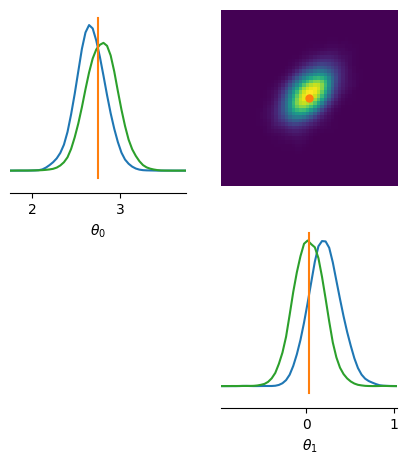

In [7]:
#plot posteriors overlayed

_ = pairplot(
            samples=[samples1, samples2],
            points=theta_observed,
            limits=list(zip(theta_observed.flatten() - 1.0, theta_observed.flatten() + 1.0, strict=False)),
            upper="kde",
            diag="kde",
            figsize=(5, 5),
            labels=[rf"$\theta_{d}$" for d in range(samples1.shape[1])],
            )

In [8]:
## Analytic KL Defintions:

# defining myself from pen and paper
def kl_gaussian_explicit(mu_p, Sigma_p, mu_q, Sigma_q):
    """
    KL( N(mu_p, Sigma_p) || N(mu_q, Sigma_q) )
    Works for d=2 (and any d), assumes Sigma_* are SPD.
    Returns a scalar tensor.
    """
    mu_p = torch.as_tensor(mu_p)
    mu_q = torch.as_tensor(mu_q)
    Sigma_p = torch.as_tensor(Sigma_p)
    Sigma_q = torch.as_tensor(Sigma_q)

    d = mu_p.numel()

    # Cholesky factors (SPD -> exists)
    Lp = torch.linalg.cholesky(Sigma_p)
    Lq = torch.linalg.cholesky(Sigma_q)

    # log |Sigma| via Cholesky: logdet = 2 * sum(log(diag(L)))
    logdet_p = 2.0 * torch.sum(torch.log(torch.diagonal(Lp)))
    logdet_q = 2.0 * torch.sum(torch.log(torch.diagonal(Lq)))

    # tr(Sigma_q^{-1} Sigma_p) using solves
    X = torch.cholesky_solve(Sigma_p, Lq)   # solves Sigma_q X = Sigma_p
    tr_term = torch.trace(X)

    # quadratic term (mu_q - mu_p)^T Sigma_q^{-1} (mu_q - mu_p)
    delta = (mu_q - mu_p).unsqueeze(-1)     # (d,1)
    v = torch.cholesky_solve(delta, Lq)     # Sigma_q^{-1} delta
    quad_term = (delta.transpose(-2, -1) @ v).squeeze()

    kl = 0.5 * ((logdet_q - logdet_p) - d + tr_term + quad_term)
    return kl

# using pytorch
def kl_gaussian_builtin(mu_p, Sigma_p, mu_q, Sigma_q):
    p = MultivariateNormal(mu_p, covariance_matrix=Sigma_p)
    q = MultivariateNormal(mu_q, covariance_matrix=Sigma_q)
    return torch.distributions.kl_divergence(p, q)


analytic_kl = kl_gaussian_explicit(mu_post1, Sigma_post1, mu_post2, Sigma_post2)
analytic_kl_pytorch = kl_gaussian_builtin(mu_post1, Sigma_post1, mu_post2, Sigma_post2)



In [9]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error

def calibrate_null_dkl(null_posterior, prior, N, n_theta, loc1, scale1, loc2, scale2):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 200 == 0:
            print(f"{i}/{N}")

        
        #print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0)

        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) #obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


0/1000
200/1000
400/1000
600/1000
800/1000


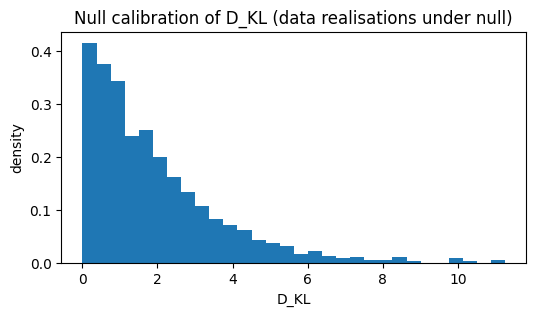

Null 95 percent critical value: 5.308700561523436
DKL observed: 1.6798337697982788
analytic_kl=1.6577298641204834
analytic_kl_pytorch=tensor([1.6577])


In [35]:

dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs1, x_obs2, n_theta = 2000)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior,1000,2000, loc1, scale1, loc2, scale2)
print("DKL observed:", dkl_obs)    
print(f"analytic_kl={analytic_kl}")
print(f"analytic_kl_pytorch={analytic_kl_pytorch}")


In [ ]:
#loop through N vals to see error as fn of n
N_theta_vals = [100,500,1000,5000,10000]

# empty array to store values
mean_vals=[0]*len(N_theta_vals)
std_dev_vals = [0]*len(N_theta_vals)
error_vals = [0]*len(N_theta_vals)

# generate some random test data, following same process:
def generate_loop_data(prior,loc1, scale1, loc2, scale2):
        theta_i = prior.sample((1,)).squeeze(0)
        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) #obtaining summary statistics of data
        return x1_i, x2_i

x1_loop, x2_loop = generate_loop_data(prior, loc1, scale1, loc2, scale2)

for i in range(len(N_theta_vals)):
        n_theta = N_theta_vals[i]
        mean_vals[i], std_dev_vals[i], error_vals[i] = calc_dkl(posterior1_direct, posterior1_direct, x1_loop, x2_loop, n_theta = n_theta)
        print(i)

0
1
2
3
4


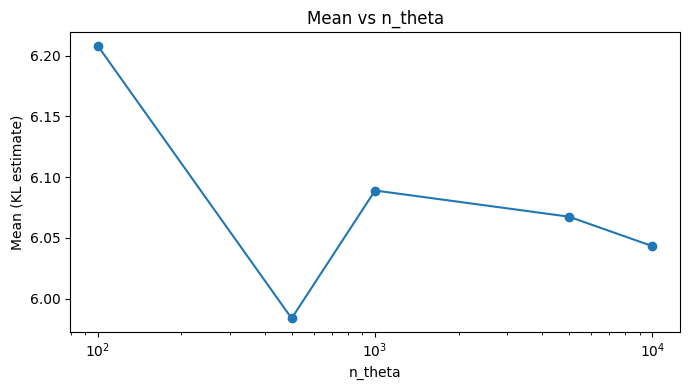

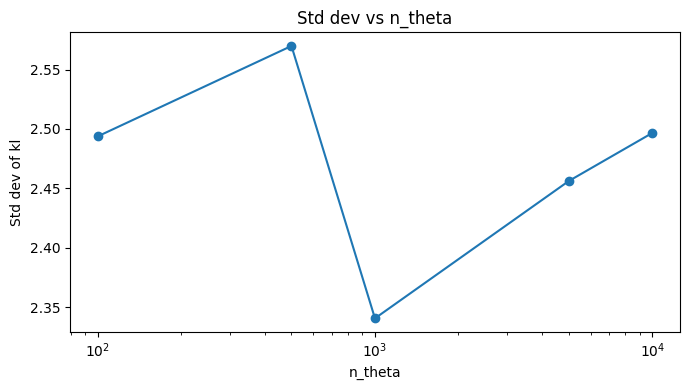

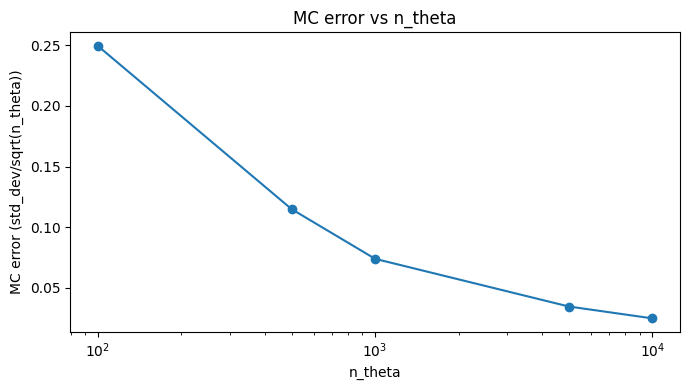

In [ ]:

N_theta_vals = np.array(N_theta_vals, dtype=float)
mean_vals = np.array(mean_vals, dtype=float)
std_dev_vals = np.array(std_dev_vals, dtype=float)
error_vals = np.array(error_vals, dtype=float)

# Plot mean
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, mean_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Mean (KL estimate)")
plt.title("Mean vs n_theta")
plt.tight_layout()
plt.show()

# 2) Std dev vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, std_dev_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Std dev of kl")
plt.title("Std dev vs n_theta")
plt.tight_layout()
plt.show()

# 3) Error vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, error_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("MC error (std_dev/sqrt(n_theta))")
plt.title("MC error vs n_theta")
plt.tight_layout()
plt.show()


In [15]:
from scipy.stats import chi2

def calibrate_null_dkl_and_perturbed(null_posterior, prior, N, n_theta, loc1, scale1, loc2, scale2,eps):

    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 100 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0)
        
        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) #obtaining summary statistics of data
        #### Try more perturbation ideas       
        x1_i_perturbed = noisy_correlated_simulator(theta_i, loc1, scale1,eps) # added correlation
      
        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    
    # analytic Dkl distn
    s = float(scale1) 
    c = 2.0 / (s + 2.0)
    x_max = max(np.max(dkls), 15.0) 
    x_vals = np.linspace(0.01, x_max, 200)
    pdf_theoretical = (1.0 / c) * chi2.pdf(x_vals / c, df=2)

    #plot histograms
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True, alpha=0.8, label='NPE Posteriors')
    plt.plot(x_vals, pdf_theoretical, 'r', lw=1, label='Theoretical Scaled $\chi^2_2$')
    plt.legend()
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Perturbed calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)

    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed

0/1000
100/1000
200/1000
300/1000
400/1000
500/1000
600/1000
700/1000
800/1000
900/1000


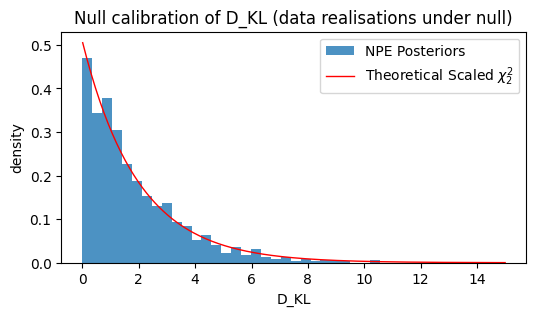

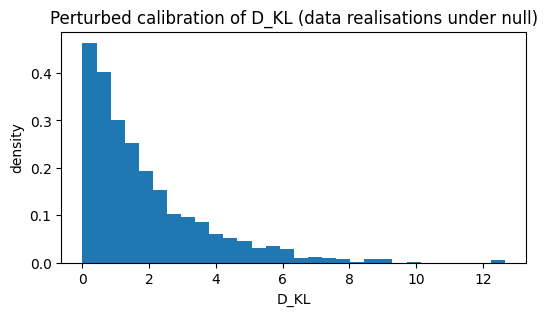

Null 95 percent critical value: 5.382463145256041
Perturbed 95 percent critical value: 5.542431712150573


In [16]:
dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed = calibrate_null_dkl_and_perturbed(posterior1_direct, prior,1000,2000, loc1, scale1, loc1, scale1, eps)